In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

2026-06-07 16:13:11.807421: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/Desilva/miniconda3/envs/ml_env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Dataset",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

2026-06-07 16:13:49.665954: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 1 of 256
2026-06-07 16:14:04.786610: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 10 of 256
2026-06-07 16:14:04.786632: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 11 of 256
2026-06-07 16:14:14.241312: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 18 of 256
2026-06-07 16:14:32.869923: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 26 of 256
2026-06-07 16:14:32.869954: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 27 of 256
2026-06-07 16:14:46.878502: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this m

(32, 256, 256, 3)
[1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 1 2 0 0]


2026-06-07 16:18:01.838354: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 42 of 256
2026-06-07 16:18:09.486094: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] Shuffle buffer filled.


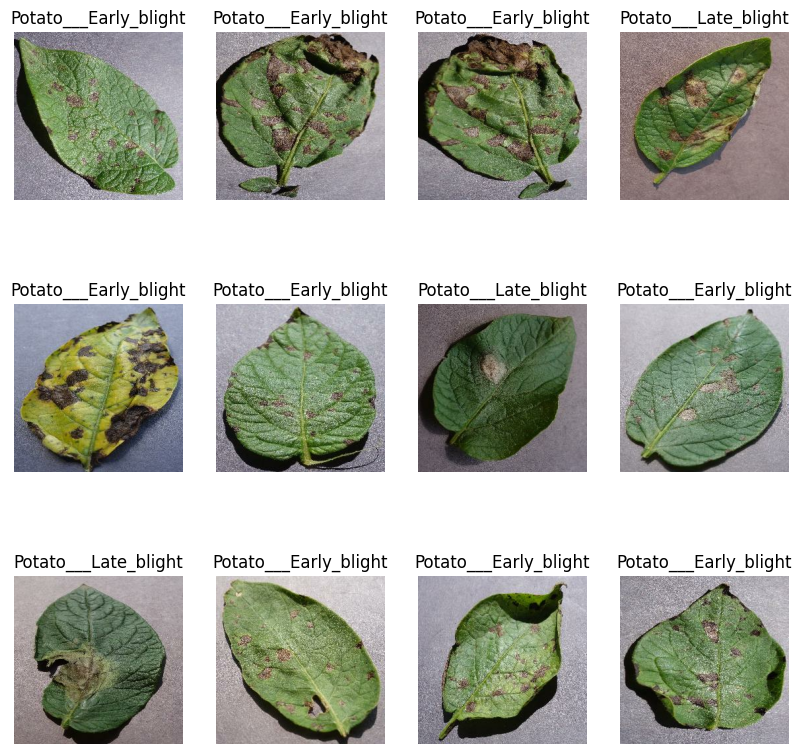

In [6]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [7]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [8]:
train_ds = dataset.take(54)
len(train_ds)

54

In [9]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [10]:
val_size=0.1
len(dataset)*val_size

6.800000000000001

In [11]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [12]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [13]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [14]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [15]:
len(train_ds)

54

In [16]:
len(val_ds)

6

In [17]:
len(test_ds)

8

In [18]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [19]:
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.experimental.preprocessing.Rescaling(1./255),
])

In [20]:
data_augmentation = tf.keras.Sequential([
  layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  layers.experimental.preprocessing.RandomRotation(0.2),
])

In [21]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [22]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 conv2d (Conv2D)             (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (32, 127, 127, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (32, 62, 62, 64)          0         
 g2D)                                                 

In [23]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=50,
)

Epoch 1/50


2026-06-07 16:20:00.863657: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 2 of 10000
2026-06-07 16:20:43.850992: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 3 of 10000
2026-06-07 16:21:32.732941: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 4 of 10000
2026-06-07 16:22:05.305969: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 5 of 10000
2026-06-07 16:22:17.167679: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 6 of 10000
2026-06-07 16:22:26.369689: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 7 of 10000
2026-06-07 16:22:40.093942: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer 

54/54 [==============================] - ETA: 0s - loss: 0.9144 - accuracy: 0.4630

2026-06-07 16:34:54.406920: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 42 of 256
2026-06-07 16:35:05.020328: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 96 of 256
2026-06-07 16:35:14.550531: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 151 of 256
2026-06-07 16:35:24.832179: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 199 of 256
2026-06-07 16:35:34.640173: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 249 of 256
2026-06-07 16:35:35.518023: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] Shuffle buffer filled.
2026-06-07 16:35:42.476281: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 1 of 10000
2026-

54/54 [==============================] - 1714s 17s/step - loss: 0.9144 - accuracy: 0.4630 - val_loss: 0.9179 - val_accuracy: 0.4896
Epoch 2/50
54/54 [==============================] - 138s 3s/step - loss: 0.7428 - accuracy: 0.6331 - val_loss: 0.6901 - val_accuracy: 0.6875
Epoch 3/50
54/54 [==============================] - 116s 2s/step - loss: 0.4445 - accuracy: 0.8027 - val_loss: 0.3796 - val_accuracy: 0.8333
Epoch 4/50
54/54 [==============================] - 109s 2s/step - loss: 0.3580 - accuracy: 0.8513 - val_loss: 0.5919 - val_accuracy: 0.7917
Epoch 5/50
54/54 [==============================] - 102s 2s/step - loss: 0.2404 - accuracy: 0.8993 - val_loss: 0.2725 - val_accuracy: 0.8854
Epoch 6/50
54/54 [==============================] - 89s 2s/step - loss: 0.2565 - accuracy: 0.8953 - val_loss: 0.2483 - val_accuracy: 0.9010
Epoch 7/50
54/54 [==============================] - 102s 2s/step - loss: 0.1629 - accuracy: 0.9346 - val_loss: 0.1443 - val_accuracy: 0.9375
Epoch 8/50
54/54 [=====

In [25]:
scores = model.evaluate(test_ds)
scores

2026-06-07 18:21:52.547494: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 38 of 256
2026-06-07 18:22:01.667068: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 79 of 256
2026-06-07 18:22:13.370899: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 133 of 256
2026-06-07 18:22:21.658796: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 167 of 256
2026-06-07 18:22:31.814942: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 210 of 256
2026-06-07 18:22:41.488083: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 254 of 256
2026-06-07 18:22:41.720835: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] Shuffle buffer filled.
2026-

8/8 [==============================] - 882s 472ms/step - loss: 0.0695 - accuracy: 0.9805


[0.06947062164545059, 0.98046875]

In [26]:
history

In [27]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [28]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [29]:
history.history["accuracy"]

[0.46296295523643494,
 0.6331018805503845,
 0.8026620149612427,
 0.8512731194496155,
 0.8993055820465088,
 0.8952546119689941,
 0.9346064925193787,
 0.9380787014961243,
 0.9392361044883728,
 0.9444444179534912,
 0.9560185074806213,
 0.9537037014961243,
 0.9623842835426331,
 0.9525462985038757,
 0.9594907164573669,
 0.9710648059844971,
 0.9629629850387573,
 0.9612268805503845,
 0.9606481194496155,
 0.9728009104728699,
 0.9785879850387573,
 0.9710648059844971,
 0.9756944179534912,
 0.9745370149612427,
 0.9774305820465088,
 0.9751157164573669,
 0.9803240895271301,
 0.9565972089767456,
 0.9664351940155029,
 0.9774305820465088,
 0.9849537014961243,
 0.9814814925193787,
 0.9733796119689941,
 0.9826388955116272,
 0.9901620149612427,
 0.9855324029922485,
 0.9716435074806213,
 0.9918981194496155,
 0.9913194179534912,
 0.9837962985038757,
 0.9855324029922485,
 0.9913194179534912,
 0.9907407164573669,
 0.9814814925193787,
 0.9837962985038757,
 0.9861111044883728,
 0.9878472089767456,
 0.983217597

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

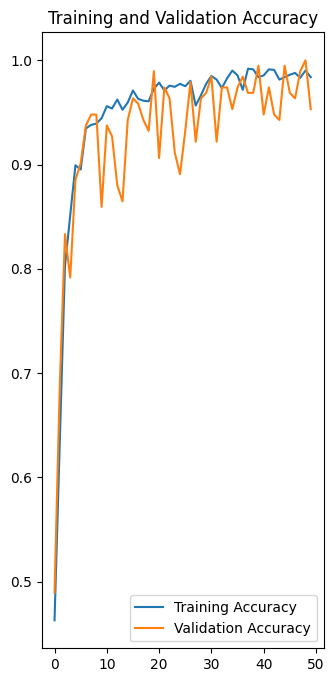

In [31]:
# Plot Training and Validation Accuracy
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

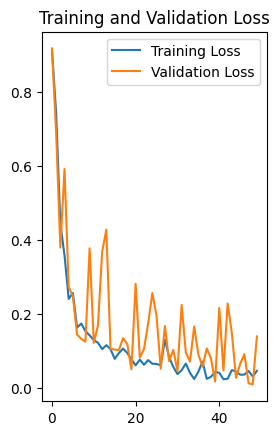

In [32]:
# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Potato___Late_blight
1/1 [==============================] - 2s 2s/step
predicted label: Potato___Late_blight


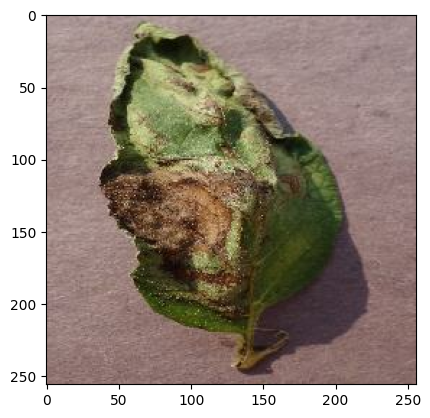

In [33]:
import numpy as np

for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)

    print("actual label:", class_names[first_label])

    batch_prediction = model.predict(images_batch)

    print(
        "predicted label:",
        class_names[np.argmax(batch_prediction[0])]
    )

In [39]:
def predict(model, image):
    
    img_array = tf.keras.preprocessing.image.img_to_array(image)

    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(predictions[0])]

    confidence = round(100 * np.max(predictions[0]),2)

    return predicted_class, confidence

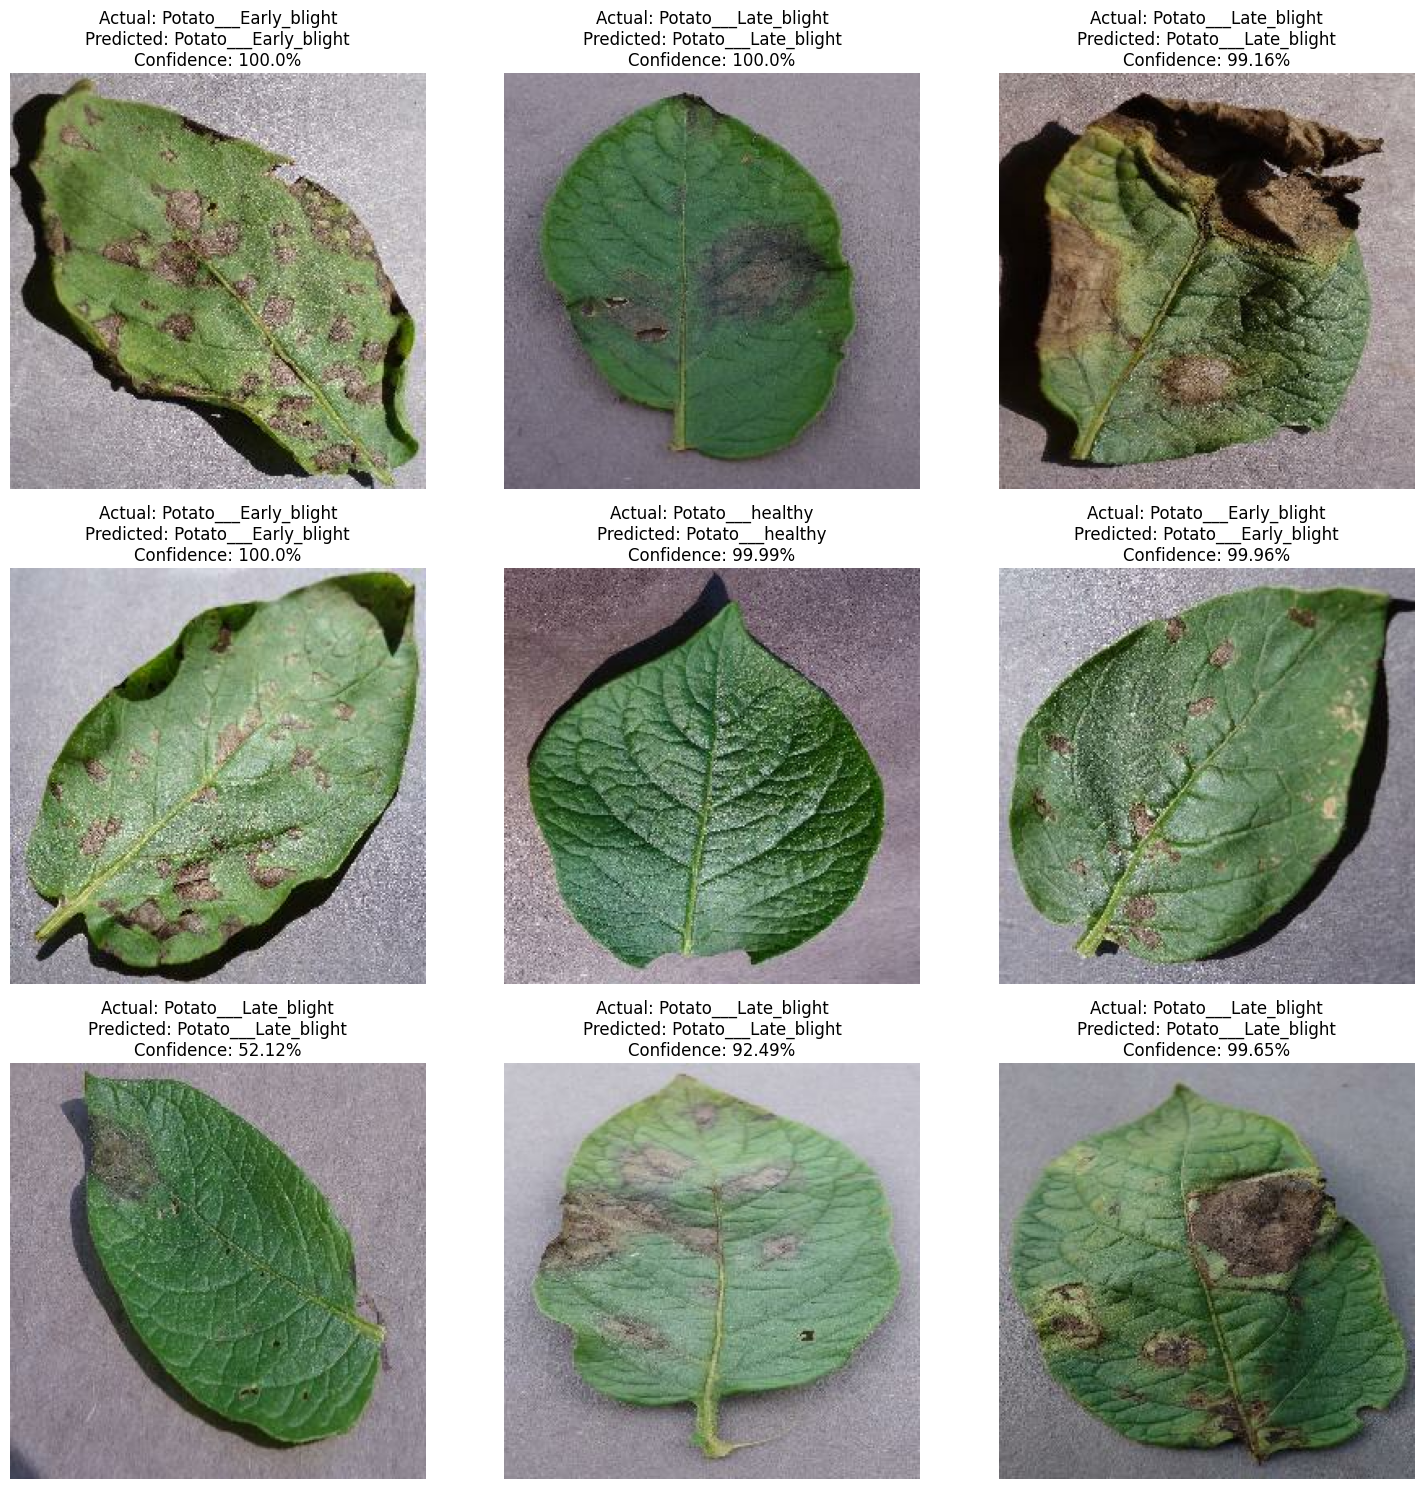

In [40]:
plt.figure(figsize=(15, 15))

for images, labels in test_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(
            model,
            images[i].numpy()
        )

        actual_class = class_names[int(labels[i])]

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence}%"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
model.save("model_potatoes.h5")